# 📊 타이타닉 생존자 예측 데이터 분석
* **목적:** 승객 데이터를 바탕으로 생존 여부에 영향을 미친 요인을 분석하고, 머신러닝으로 생존율을 예측합니다.
* **작성자:** 세희

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Seaborn 자체 데이터셋 활용
df = sns.load_dataset('titanic')

# 데이터 상단 5행 확인
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


### 🔍 1. 성별에 따른 생존율 시각화
성별에 따라 생존율에 유의미한 차이가 있는지 시각적으로 확인합니다.

/tmp/ipykernel_1697/1155154047.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='sex', y='survived', data=df, ci=None)


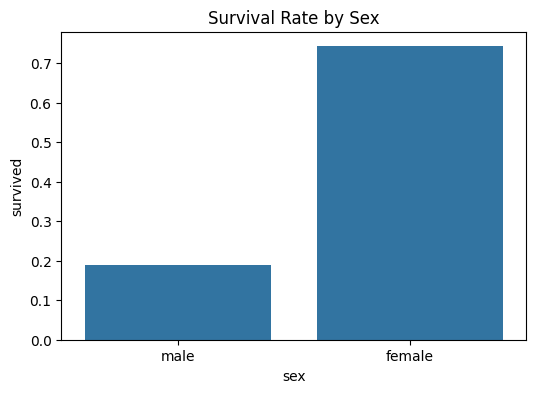

In [2]:
plt.figure(figsize=(6, 4))
sns.barplot(x='sex', y='survived', data=df, ci=None)
plt.title('Survival Rate by Sex')
plt.show()

### 🛠️ 2. 데이터 전처리
* 결측치가 존재하는 Age 컬럼은 중앙값(Median)으로 채웁니다.
* Sex 컬럼은 숫자로 변환(male: 0, female: 1)합니다.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# 결측치 처리
df['age'] = df['age'].fillna(df['age'].median())

# 범주형 데이터 숫자로 변환
df['sex'] = df['sex'].map({'male': 0, 'female': 1})

# 피처(X)와 타겟(y) 분리
X = df[['pclass', 'sex', 'age', 'fare']]
y = df['survived']

# 학습용/테스트용 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest 모델 생성 및 학습
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 예측 및 정확도 측정
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'🎯 모델 정확도(Accuracy): {accuracy * 100:.2f}%')

🎯 모델 정확도(Accuracy): 79.33%
